# COVID-19 EDA and Forecasting (India)
This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the COVID-19 dataset for India, checks data quality, explores correlations, and builds an advanced time-series forecasting model using Meta's Prophet.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from prophet import Prophet
from statsmodels.tsa.seasonal import seasonal_decompose

# Set plotly renderer so graphs render offline in the notebook
import plotly.io as pio
pio.renderers.default = 'png'

# Set Seaborn theme
sns.set_theme(style='darkgrid')

# Load Data
hist_df = pd.read_csv('../data/covid_19_india_historical.csv')
hist_df['Date'] = pd.to_datetime(hist_df['Date'])
state_df = pd.read_csv('../data/StatewiseTestingDetails.csv')
print('Data loaded successfully!')


Data loaded successfully!


## 1. Data Quality and Summary Statistics
Checking for missing values and getting a statistical overview of the data.

In [2]:
display(hist_df.info())
display(state_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             1143 non-null   datetime64[ns]
 1   Total Cases      1143 non-null   int64         
 2   Total Deaths     1143 non-null   int64         
 3   Total Recovered  1143 non-null   int64         
 4   Daily New Cases  1143 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 44.8 KB


None

,Active Cases,Total Recovered,Total Deaths,Total Confirmed,todayActive,todayRecovered,todayDeaths,todayCases
count,36.000000,3.600000e+01,36.000000,3.600000e+01,36.000000,36.000000,36.0,36.000000
mean,6.861111,1.236302e+06,14822.833333,1.251133e+06,0.611111,5.888889,0.0,6.500000
std,19.415977,1.822644e+06,27241.027323,1.848355e+06,8.606568,14.479104,0.0,19.310249
min,0.000000,1.063700e+04,4.000000,1.076600e+04,-13.000000,0.000000,0.0,0.000000
25%,0.000000,1.056232e+05,1125.250000,1.066270e+05,0.000000,0.000000,0.0,0.000000
50%,0.000000,6.078015e+05,6557.500000,6.142170e+05,0.000000,0.000000,0.0,0.000000
75%,4.500000,1.323414e+06,14334.750000,1.333043e+06,0.000000,2.250000,0.0,3.000000
max,106.000000,8.029028e+06,148602.000000,8.177736e+06,46.000000,60.000000,0.0,106.000000


## 2. Exploratory Data Analysis (EDA)
Visualizing historical trends and state-wise distributions.

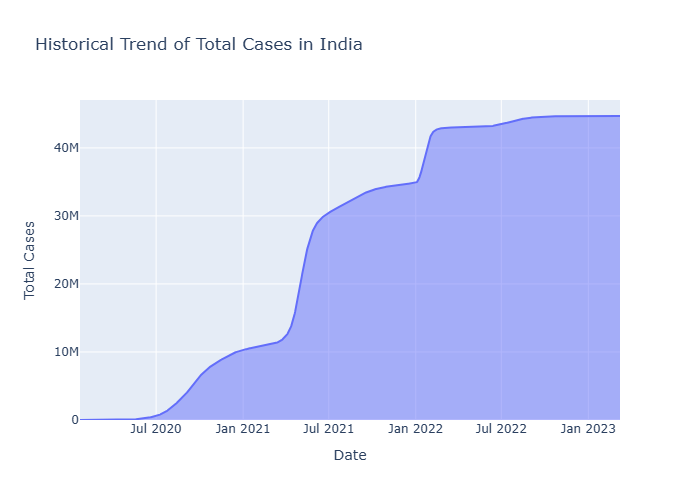

In [3]:
# Plot Historical Cases using Plotly
fig = px.area(hist_df, x='Date', y='Total Cases', title='Historical Trend of Total Cases in India')
fig.show()

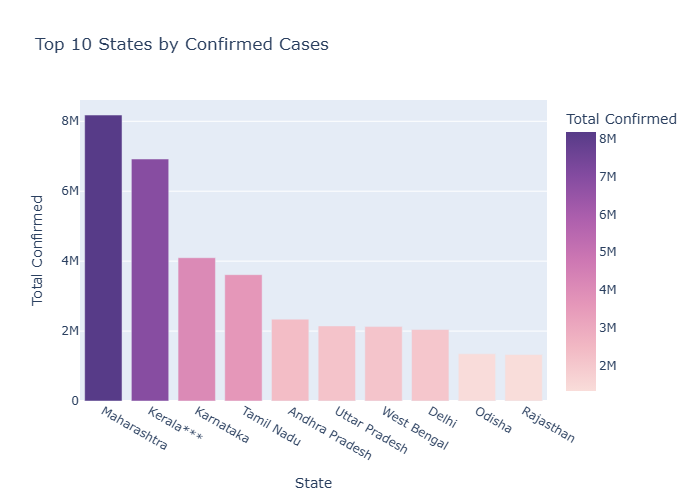

In [4]:
# State-wise Bar Chart
top_states = state_df.sort_values(by='Total Confirmed', ascending=False).head(10)
fig2 = px.bar(top_states, x='State', y='Total Confirmed', title='Top 10 States by Confirmed Cases', color='Total Confirmed', color_continuous_scale='Purpor')
fig2.show()

## 3. Correlation Analysis
Understanding how different metrics correlate with each other (e.g. Confirmed vs Deaths).

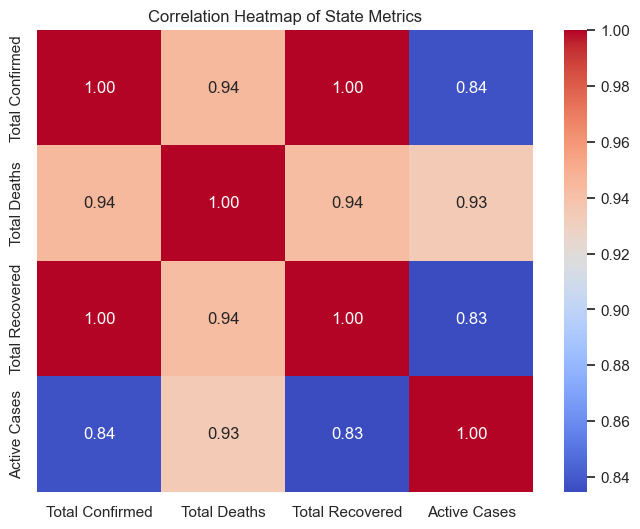

In [5]:
numeric_cols = ['Total Confirmed', 'Total Deaths', 'Total Recovered', 'Active Cases']
plt.figure(figsize=(8,6))
sns.heatmap(state_df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of State Metrics')
plt.show()

## 4. Time Series Analysis & Forecasting
Decomposing the daily new cases to find trends and seasonality, followed by a Prophet forecast.

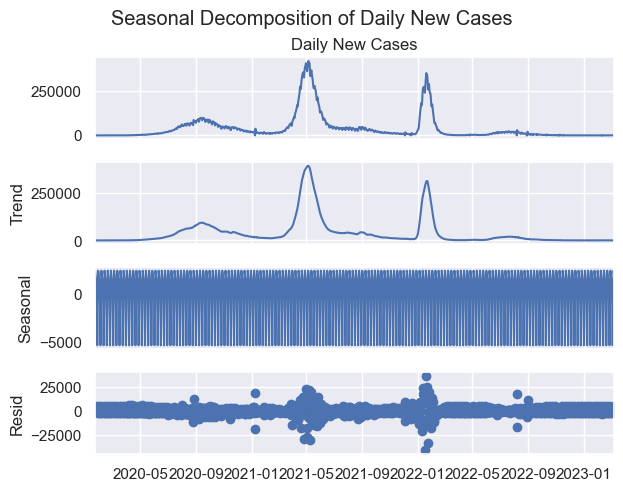

In [6]:
# Seasonal Decomposition
hist_df.set_index('Date', inplace=True)
result = seasonal_decompose(hist_df['Daily New Cases'], model='additive', period=7)
result.plot()
plt.suptitle('Seasonal Decomposition of Daily New Cases', y=1.02)
plt.show()
hist_df.reset_index(inplace=True)


15:08:20 - cmdstanpy - INFO - Chain [1] start processing


15:08:20 - cmdstanpy - INFO - Chain [1] done processing


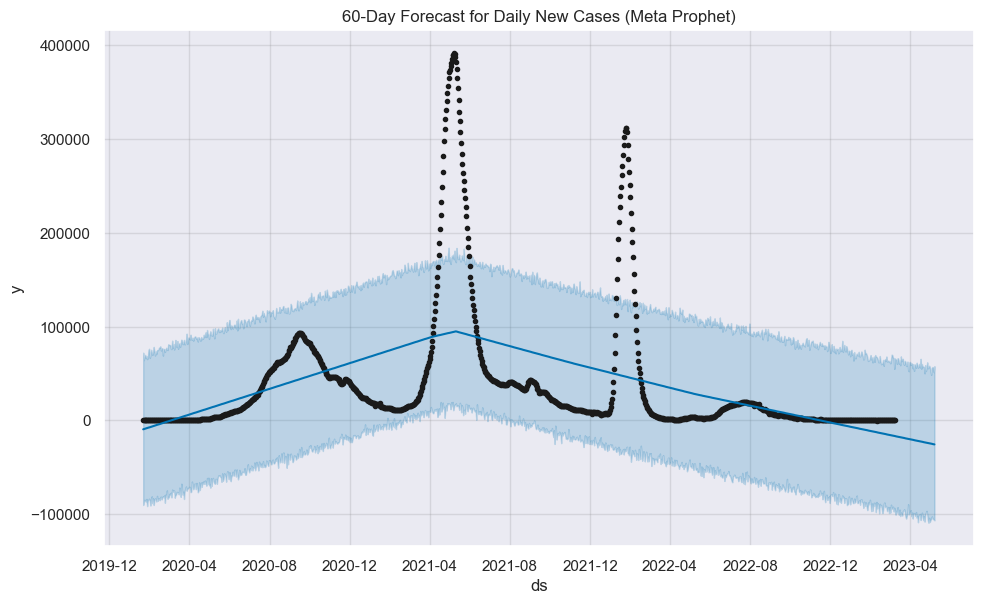

In [7]:
# Time Series Forecasting using Prophet
series = hist_df[['Date', 'Daily New Cases']].copy()
series.columns = ['ds', 'y']
# Apply a 7-day rolling average to smooth out reporting inconsistencies
series['y'] = series['y'].rolling(window=7).mean().fillna(0)

m = Prophet(yearly_seasonality=False, daily_seasonality=False)
m.fit(series)
future = m.make_future_dataframe(periods=60)
forecast = m.predict(future)

# Plot Forecast
fig3 = m.plot(forecast)
plt.title('60-Day Forecast for Daily New Cases (Meta Prophet)')
plt.show()
